# Speech Commands Audio Similarity using YAMNet

## Objective
This notebook loads multiple audio clips from the TensorFlow Speech Commands dataset, extracts embeddings using the pretrained YAMNet model, computes pairwise similarity and distance scores, and visualizes them.

## Dataset
Speech Commands Dataset
https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz

## Pretrained Model
YAMNet
https://tfhub.dev/google/yamnet/1

In [1]:
!pip -q install tensorflow tensorflow-hub librosa seaborn

In [2]:
import os
import glob
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_hub as hub

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances

In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz"

data_dir = tf.keras.utils.get_file(
    "speech_commands",
    origin=dataset_url,
    untar=True
)

print(data_dir)

2428923189/2428923189 ━━━━━━━━━━━━━━━━━━━━ 26s 0us/step
/root/.keras/datasets/speech_commands


# Load YAMNet Model

In [4]:
yamnet = hub.load("https://tfhub.dev/google/yamnet/1")

# Load Audio Files

In [5]:
classes = [
    "yes",
    "no",
    "up",
    "down",
    "left",
    "right"
]

audio_files = []
labels = []

for cls in classes:

    files = glob.glob(os.path.join(data_dir, cls, "*.wav"))

    audio_files.append(files[0])
    labels.append(cls)

print(audio_files)

['/root/.keras/datasets/speech_commands/yes/e3e0f145_nohash_1.wav', '/root/.keras/datasets/speech_commands/no/e3e0f145_nohash_1.wav', '/root/.keras/datasets/speech_commands/up/e3e0f145_nohash_1.wav', '/root/.keras/datasets/speech_commands/down/e3e0f145_nohash_1.wav', '/root/.keras/datasets/speech_commands/left/e3e0f145_nohash_1.wav', '/root/.keras/datasets/speech_commands/right/e3e0f145_nohash_1.wav']


# Read Audio Clips

In [6]:
waveforms = []

for file in audio_files:

    audio, sr = librosa.load(
        file,
        sr=16000
    )

    waveforms.append(audio.astype(np.float32))

print("Loaded", len(waveforms), "audio clips")

Loaded 6 audio clips


# Extract Audio Embeddings

In [7]:
embeddings = []

for waveform in waveforms:

    scores, embedding, spectrogram = yamnet(waveform)

    embedding = tf.reduce_mean(
        embedding,
        axis=0
    )

    embeddings.append(
        embedding.numpy()
    )

embeddings = np.array(embeddings)

print(embeddings.shape)

(6, 1024)


# Compute Cosine Similarity

In [8]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[1.         0.73996854 0.6802083  0.846762   0.9141028  0.88064855]
 [0.73996854 1.         0.7245313  0.83936316 0.77769077 0.72334677]
 [0.6802083  0.7245313  1.0000002  0.7922267  0.77460545 0.65709937]
 [0.846762   0.83936316 0.7922267  1.         0.90978163 0.86029   ]
 [0.9141028  0.77769077 0.77460545 0.90978163 1.0000002  0.88125193]
 [0.88064855 0.72334677 0.65709937 0.86029    0.88125193 1.        ]]


# Compute Euclidean Distance Matrix

In [9]:
distance_matrix = pairwise_distances(
    embeddings,
    metric="euclidean"
)

print(distance_matrix)

[[0.        4.755517  5.0200996 3.665122  2.742418  5.5816083]
 [4.755517  0.        4.4877486 3.6439729 4.1554084 7.3620763]
 [5.0200996 4.4877486 0.        3.9489691 3.8772614 8.065495 ]
 [3.665122  3.6439729 3.9489691 0.        2.680271  5.9602323]
 [2.742418  4.1554084 3.8772614 2.680271  0.        5.949558 ]
 [5.5816083 7.3620763 8.065495  5.9602323 5.949558  0.       ]]


# Similarity Heatmap

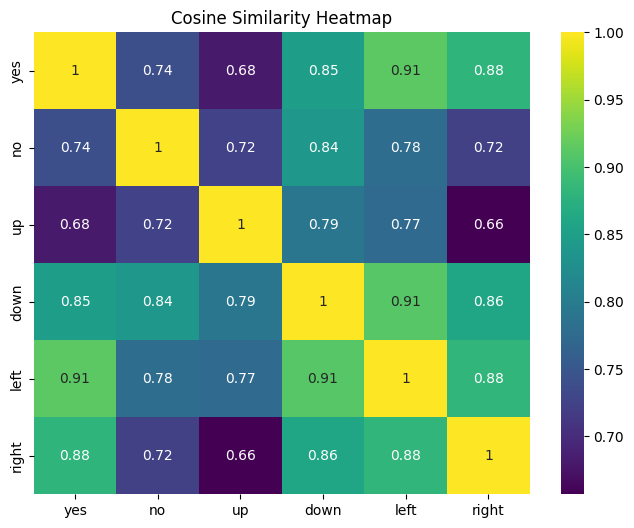

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Cosine Similarity Heatmap")

plt.show()

# Distance Matrix

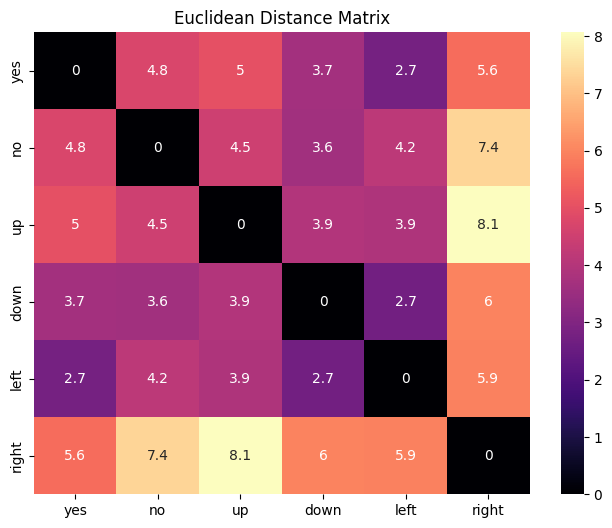

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    distance_matrix,
    annot=True,
    cmap="magma",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Euclidean Distance Matrix")

plt.show()

# Observations

1. Each audio clip is converted into a 1024-dimensional embedding using YAMNet.

2. Cosine similarity values closer to 1 indicate similar audio embeddings.

3. Euclidean distance values closer to 0 indicate similar audio clips.

4. The similarity heatmap provides a visual comparison of all speech commands.

5. The diagonal entries show maximum similarity and minimum distance because each audio clip is compared with itself.